### data 확인 및 결측치 처리

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/heart.csv')
list(df.columns)
hd = df[df['HeartDisease'] == 1]
hd.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
3,48,F,ASY,NaN,214,NaN,Normal,108,Y,1.0
8,37,M,ASY,NaN,207,NaN,Normal,130,Y,1.0
11,58,M,ATA,136.0,164,NaN,ST,99,Y,1.0
13,49,M,ASY,140.0,234,NaN,Normal,140,Y,1.0
16,38,M,ASY,110.0,196,NaN,Normal,166,N,1.0


In [ ]:
for i in df.columns:
    missingValueRate = df[i].isna().sum() / len(df) * 100
    if missingValueRate > 0:
        print(f'{i} null rate : {round(missingValueRate, 2)}')

In [ ]:
df['FastingBS'] = df['FastingBS'].fillna(0)
df['RestingBP'] = df['RestingBP'].replace(np.nan, df['RestingBP'].median())
df.dropna(axis=0, inplace=True)
# df.info()
df.to_csv('../data/clean_heart.csv')
heart = pd.read_csv('../data/clean_heart.csv')
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      916 non-null    int64  
 1   Age             916 non-null    int64  
 2   Sex             916 non-null    str    
 3   ChestPainType   916 non-null    str    
 4   RestingBP       916 non-null    float64
 5   Cholesterol     916 non-null    int64  
 6   FastingBS       916 non-null    float64
 7   RestingECG      916 non-null    str    
 8   MaxHR           916 non-null    int64  
 9   ExerciseAngina  916 non-null    str    
 10  HeartDisease    916 non-null    float64
dtypes: float64(3), int64(4), str(4)
memory usage: 78.8 KB


### 통계값 요약
> 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 1분위수(25%), 중앙값(50%), 3분위
수(75%), 최댓값(max)

In [13]:
heart[['Age', 'MaxHR', 'Cholesterol']].describe()
heart.groupby(['HeartDisease', 'ChestPainType'])[['Age', 'MaxHR', "Cholesterol"]].mean()

Age       MaxHR  Cholesterol
HeartDisease ChestPainType                                    
0.0          ASY            52.317308  138.548077   226.865385
             ATA            48.236486  152.621622   232.668919
             NAP            51.045802  150.641221   221.503817
             TA             54.692308  150.500000   222.730769
1.0          ASY            55.660714  125.806122   175.974490
             ATA            55.958333  137.500000   233.291667
             NAP            57.549296  129.394366   153.281690
             TA             55.000000  144.500000   186.700000

In [14]:
heart.groupby('Sex')['RestingBP'].mean()

Sex
F    132.119792
M    132.421271
Name: RestingBP, dtype: float64

In [23]:
def age_group(age):
    if age < 45:
        return 'Young'
    elif age < 65:
        return 'Middle-aged'
    else:
        return 'Old'
def cholesterol_risk(cholesterol):
    if cholesterol < 200:
        return 'Low'
    elif cholesterol < 240:
        return 'Medium'
    else:
        return 'High'
heart['age_group'] = heart['Age'].apply(age_group)
heart['CholesterolRisk'] = heart['Cholesterol'].apply(cholesterol_risk)
heart['ExerciseAnginaBinary'] = (heart['ExerciseAngina'] == 'Y').astype(int)
heart['RestingECG_Normal'] = (heart['RestingECG'] == 'Normal').astype(int)
heart['RestingECG_ST'] = (heart['RestingECG'] == 'ST').astype(int)
heart['RestingECG_LVH'] = (heart['RestingECG'] == 'LVH').astype(int)
heart['MaxHR_Ratio'] = (heart['MaxHR'] / (220 - heart['Age']))
heart['Log_chol'] = np.log(heart['Cholesterol'] + 1)
heart.head()

,Unnamed: 0,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease,age_group,CholesterolRisk,ExerciseAnginaBinary,RestingECG_Normal,RestingECG_ST,RestingECG_LVH,MaxHR_Ratio,Log_chol
0,0,40,M,ATA,140.0,289,0.0,Normal,172,N,0.0,Young,High,0,1,0,0,0.955556,5.669881
1,3,48,F,ASY,130.0,214,0.0,Normal,108,Y,1.0,Middle-aged,Medium,1,1,0,0,0.627907,5.370638
2,4,54,M,NAP,130.0,195,0.0,Normal,122,N,0.0,Middle-aged,Low,0,1,0,0,0.734940,5.278115
3,5,39,M,NAP,130.0,339,0.0,Normal,170,N,0.0,Young,High,0,1,0,0,0.939227,5.828946
4,6,45,F,ATA,130.0,237,0.0,Normal,170,N,0.0,Middle-aged,Medium,0,1,0,0,0.971429,5.472271


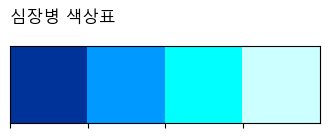

In [25]:
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic, Linux: NanumGothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

sns.palplot(['#003399','#0099FF','#00FFFF','#CCFFFF'])
plt.title("심장병 색상표", loc='left', y=1.2)
plt.show()

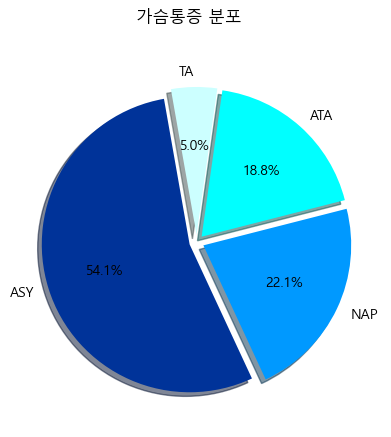

In [26]:
ratio = heart['ChestPainType'].value_counts()
plt.pie(x=ratio, labels=ratio.index, autopct='%1.1f%%', startangle=100, explode=[0.05,0.05,0.05,0.05], shadow=True, colors=['#003399','#0099FF','#00FFFF','#CCFFFF'])
plt.suptitle('가슴통증 분포')
plt.show()

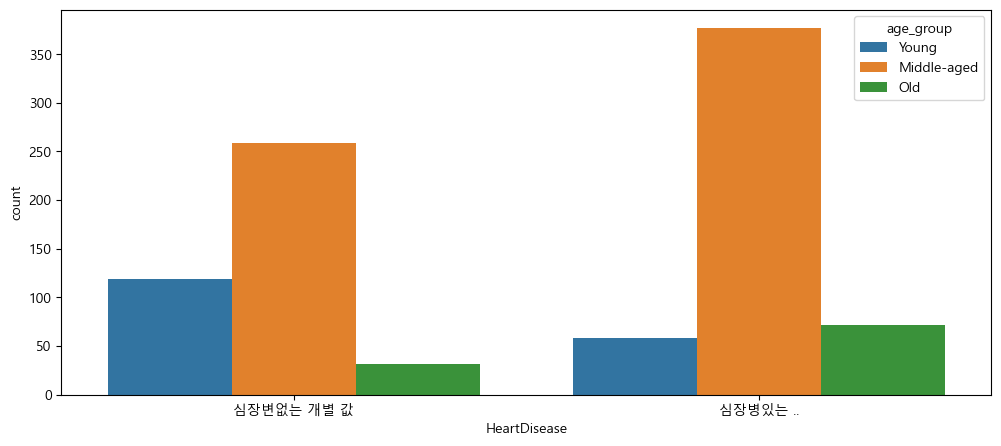

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(data=heart, x='HeartDisease', hue='ChestPainType', 
            hue_order=['ASY', 'NAP', 'ATA','TA'],
            palette=['#003399','#0099FF','#00FFFF','#CCFFFF'])
plt.xticks([0,1],['심장변없는 개별 값','심장병있는 ..'])
plt.show()
